In [314]:
import pandas as pd
import numpy as np
import platform
import matplotlib.pyplot as plt


# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
    
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [315]:
df = pd.read_csv("Courses.csv")

In [316]:
df.shape

(641138, 21)

In [317]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   index              641138 non-null  int64  
 1   course_id          641138 non-null  object 
 2   userid_DI          641138 non-null  object 
 3   registered         641138 non-null  int64  
 4   viewed             641138 non-null  int64  
 5   explored           641138 non-null  int64  
 6   certified          641138 non-null  int64  
 7   final_cc_cname_DI  641138 non-null  object 
 8   LoE_DI             535130 non-null  object 
 9   YoB                544533 non-null  float64
 10  gender             554332 non-null  object 
 11  grade              592766 non-null  object 
 12  start_time_DI      641138 non-null  object 
 13  last_event_DI      462184 non-null  object 
 14  nevents            441987 non-null  float64
 15  ndays_act          478395 non-null  float64
 16  np

### 컬럼명 소문자화

In [318]:
df.columns = df.columns.str.lower()
with pd.option_context('display.max_columns', None):
    display(df)

,index,course_id,userid_di,registered,viewed,explored,certified,final_cc_cname_di,loe_di,yob,gender,grade,start_time_di,last_event_di,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaN,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641133,641133,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,1991.0,m,NaN,2013-09-07,2013-09-07,97.0,1.0,4.0,2.0,0,NaN,NaN
641134,641134,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,1991.0,f,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,NaN
641135,641135,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,1979.0,m,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,NaN
641136,641136,MITx/6.00x/2013_Spring,MHxPC130098513,1,1,0,0,United States,Doctorate,1979.0,m,NaN,2013-09-07,2013-09-07,74.0,1.0,14.0,1.0,0,NaN,NaN


### 데이터 타입 변경

In [319]:
date_cols = ['start_time_di', 'last_event_di']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [320]:
numeric_cols = ['yob', 'grade']

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [321]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   index              641138 non-null  int64         
 1   course_id          641138 non-null  object        
 2   userid_di          641138 non-null  object        
 3   registered         641138 non-null  int64         
 4   viewed             641138 non-null  int64         
 5   explored           641138 non-null  int64         
 6   certified          641138 non-null  int64         
 7   final_cc_cname_di  641138 non-null  object        
 8   loe_di             535130 non-null  object        
 9   yob                544533 non-null  float64       
 10  gender             554332 non-null  object        
 11  grade              583738 non-null  float64       
 12  start_time_di      641138 non-null  datetime64[ns]
 13  last_event_di      462184 non-null  datetime

### 컬럼명 변경

In [322]:
df.rename(columns={
    'userid_di': 'user_id',
    'final_cc_cname_di': 'nationality',
    'loe_di': 'loe',
    'start_time_di': 'start_time',
    'last_event_di': 'last_event'
}, inplace=True)

In [323]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 21 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   index            641138 non-null  int64         
 1   course_id        641138 non-null  object        
 2   user_id          641138 non-null  object        
 3   registered       641138 non-null  int64         
 4   viewed           641138 non-null  int64         
 5   explored         641138 non-null  int64         
 6   certified        641138 non-null  int64         
 7   nationality      641138 non-null  object        
 8   loe              535130 non-null  object        
 9   yob              544533 non-null  float64       
 10  gender           554332 non-null  object        
 11  grade            583738 non-null  float64       
 12  start_time       641138 non-null  datetime64[ns]
 13  last_event       462184 non-null  datetime64[ns]
 14  nevents          441

### 불필요 컬럼 제거

In [324]:
drop_cols = ['index','roles']

df.drop(columns=drop_cols, inplace=True)

In [325]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   course_id        641138 non-null  object        
 1   user_id          641138 non-null  object        
 2   registered       641138 non-null  int64         
 3   viewed           641138 non-null  int64         
 4   explored         641138 non-null  int64         
 5   certified        641138 non-null  int64         
 6   nationality      641138 non-null  object        
 7   loe              535130 non-null  object        
 8   yob              544533 non-null  float64       
 9   gender           554332 non-null  object        
 10  grade            583738 non-null  float64       
 11  start_time       641138 non-null  datetime64[ns]
 12  last_event       462184 non-null  datetime64[ns]
 13  nevents          441987 non-null  float64       
 14  ndays_act        478

### 데이터 정제

In [326]:
### 목적 미부합 데이터 분리
df = df[df['course_id'] != 'HarvardX/CS50x/2012'].reset_index(drop=True)

In [327]:
df

,course_id,user_id,registered,viewed,explored,certified,nationality,loe,yob,gender,grade,start_time,last_event,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag
0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0.0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,1.0
1,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0.0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,1.0
2,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0.0,2012-12-19,NaT,NaN,16.0,NaN,NaN,0,1.0
3,HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,NaN,NaN,NaN,0.0,2012-09-17,2013-05-23,502.0,16.0,50.0,12.0,0,NaN
4,HarvardX/PH278x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0.0,2013-02-08,NaT,NaN,16.0,NaN,NaN,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471512,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,1991.0,m,NaN,2013-09-07,2013-09-07,97.0,1.0,4.0,2.0,0,NaN
471513,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,1991.0,f,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN
471514,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,1979.0,m,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN
471515,MITx/6.00x/2013_Spring,MHxPC130098513,1,1,0,0,United States,Doctorate,1979.0,m,NaN,2013-09-07,2013-09-07,74.0,1.0,14.0,1.0,0,NaN


In [328]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471517 entries, 0 to 471516
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   course_id        471517 non-null  object        
 1   user_id          471517 non-null  object        
 2   registered       471517 non-null  int64         
 3   viewed           471517 non-null  int64         
 4   explored         471517 non-null  int64         
 5   certified        471517 non-null  int64         
 6   nationality      471517 non-null  object        
 7   loe              390450 non-null  object        
 8   yob              394705 non-null  float64       
 9   gender           401906 non-null  object        
 10  grade            415406 non-null  float64       
 11  start_time       471517 non-null  datetime64[ns]
 12  last_event       412504 non-null  datetime64[ns]
 13  nevents          392307 non-null  float64       
 14  ndays_act        420

In [329]:
### 결측치 처리
fill_miss_cols = ['loe', 'gender']

df[fill_miss_cols] = df[fill_miss_cols].fillna('unknown')

In [330]:
df

,course_id,user_id,registered,viewed,explored,certified,nationality,loe,yob,gender,grade,start_time,last_event,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag
0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,unknown,NaN,unknown,0.0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,1.0
1,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,unknown,NaN,unknown,0.0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,1.0
2,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,unknown,NaN,unknown,0.0,2012-12-19,NaT,NaN,16.0,NaN,NaN,0,1.0
3,HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,NaN,unknown,0.0,2012-09-17,2013-05-23,502.0,16.0,50.0,12.0,0,NaN
4,HarvardX/PH278x/2013_Spring,MHxPC130275857,1,0,0,0,United States,unknown,NaN,unknown,0.0,2013-02-08,NaT,NaN,16.0,NaN,NaN,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471512,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,1991.0,m,NaN,2013-09-07,2013-09-07,97.0,1.0,4.0,2.0,0,NaN
471513,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,1991.0,f,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN
471514,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,1979.0,m,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN
471515,MITx/6.00x/2013_Spring,MHxPC130098513,1,1,0,0,United States,Doctorate,1979.0,m,NaN,2013-09-07,2013-09-07,74.0,1.0,14.0,1.0,0,NaN


In [331]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471517 entries, 0 to 471516
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   course_id        471517 non-null  object        
 1   user_id          471517 non-null  object        
 2   registered       471517 non-null  int64         
 3   viewed           471517 non-null  int64         
 4   explored         471517 non-null  int64         
 5   certified        471517 non-null  int64         
 6   nationality      471517 non-null  object        
 7   loe              471517 non-null  object        
 8   yob              394705 non-null  float64       
 9   gender           471517 non-null  object        
 10  grade            415406 non-null  float64       
 11  start_time       471517 non-null  datetime64[ns]
 12  last_event       412504 non-null  datetime64[ns]
 13  nevents          392307 non-null  float64       
 14  ndays_act        420

In [332]:
### 최소 가입 조건 (13세 미만) 불만족 데이터 제거

# 나이 파생컬럼 생성
df['age'] = df['start_time'].dt.year - df['yob']

# age 결측치 플래깅
df['age_missing'] = df['age'].isna().astype('int64')

# 13세 미만 제거
df = df[df['age'] >= 13 | df['age'].isna()].reset_index(drop=True)

df['yob'] = df['yob'].fillna('unknown')
df['age'] = df['age'].fillna('unknown')

In [333]:
df

,course_id,user_id,registered,viewed,explored,certified,nationality,loe,yob,gender,...,start_time,last_event,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_missing
0,HarvardX/PH207x/2012_Fall,MHxPC130313697,1,0,0,0,India,Bachelor's,1989.0,m,...,2012-07-24,2013-07-27,6.0,3.0,NaN,NaN,0,NaN,23.0,0
1,HarvardX/PH207x/2012_Fall,MHxPC130237753,1,1,0,0,United States,Secondary,1993.0,m,...,2012-07-24,2012-12-24,107.0,8.0,7.0,2.0,0,NaN,19.0,0
2,HarvardX/ER22x/2013_Spring,MHxPC130283854,1,0,0,0,United States,Master's,1980.0,f,...,2012-12-19,NaT,NaN,25.0,NaN,NaN,0,1.0,32.0,0
3,HarvardX/PH278x/2013_Spring,MHxPC130283854,1,0,0,0,United States,Master's,1980.0,f,...,2012-12-19,NaT,NaN,25.0,NaN,NaN,0,1.0,32.0,0
4,HarvardX/PH207x/2012_Fall,MHxPC130317399,1,0,0,0,Australia,Master's,1980.0,f,...,2012-07-24,2012-08-25,3.0,2.0,NaN,NaN,0,NaN,32.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394499,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,1991.0,m,...,2013-09-07,2013-09-07,97.0,1.0,4.0,2.0,0,NaN,22.0,0
394500,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,1991.0,f,...,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,22.0,0
394501,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,1979.0,m,...,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,34.0,0
394502,MITx/6.00x/2013_Spring,MHxPC130098513,1,1,0,0,United States,Doctorate,1979.0,m,...,2013-09-07,2013-09-07,74.0,1.0,14.0,1.0,0,NaN,34.0,0


In [334]:
### 참여 단계 컬럼(step): 각 학생 별 진행 단계

df['step'] = np.select(
    [
        df['certified'] ==1,
        df['explored'] == 1,
        df['viewed'] == 1,
        df['registered'] == 1,
    ],
    [
        3,
        2,
        1,
        0
    ]
)

In [335]:
df

,course_id,user_id,registered,viewed,explored,certified,nationality,loe,yob,gender,...,last_event,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_missing,step
0,HarvardX/PH207x/2012_Fall,MHxPC130313697,1,0,0,0,India,Bachelor's,1989.0,m,...,2013-07-27,6.0,3.0,NaN,NaN,0,NaN,23.0,0,0
1,HarvardX/PH207x/2012_Fall,MHxPC130237753,1,1,0,0,United States,Secondary,1993.0,m,...,2012-12-24,107.0,8.0,7.0,2.0,0,NaN,19.0,0,1
2,HarvardX/ER22x/2013_Spring,MHxPC130283854,1,0,0,0,United States,Master's,1980.0,f,...,NaT,NaN,25.0,NaN,NaN,0,1.0,32.0,0,0
3,HarvardX/PH278x/2013_Spring,MHxPC130283854,1,0,0,0,United States,Master's,1980.0,f,...,NaT,NaN,25.0,NaN,NaN,0,1.0,32.0,0,0
4,HarvardX/PH207x/2012_Fall,MHxPC130317399,1,0,0,0,Australia,Master's,1980.0,f,...,2012-08-25,3.0,2.0,NaN,NaN,0,NaN,32.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394499,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,1991.0,m,...,2013-09-07,97.0,1.0,4.0,2.0,0,NaN,22.0,0,1
394500,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,1991.0,f,...,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,22.0,0,0
394501,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,1979.0,m,...,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,34.0,0,0
394502,MITx/6.00x/2013_Spring,MHxPC130098513,1,1,0,0,United States,Doctorate,1979.0,m,...,2013-09-07,74.0,1.0,14.0,1.0,0,NaN,34.0,0,1


In [336]:
## 활동일수 음수 제거
df = df[(df['start_time'] <= df['last_event']) |
        (df['start_time'].isna()) |
        (df['last_event'].isna())].reset_index(drop=True)

In [337]:
with pd.option_context('display.max_columns', None):
    display(df)

,course_id,user_id,registered,viewed,explored,certified,nationality,loe,yob,gender,grade,start_time,last_event,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_missing,step
0,HarvardX/PH207x/2012_Fall,MHxPC130313697,1,0,0,0,India,Bachelor's,1989.0,m,0.0,2012-07-24,2013-07-27,6.0,3.0,NaN,NaN,0,NaN,23.0,0,0
1,HarvardX/PH207x/2012_Fall,MHxPC130237753,1,1,0,0,United States,Secondary,1993.0,m,0.0,2012-07-24,2012-12-24,107.0,8.0,7.0,2.0,0,NaN,19.0,0,1
2,HarvardX/ER22x/2013_Spring,MHxPC130283854,1,0,0,0,United States,Master's,1980.0,f,0.0,2012-12-19,NaT,NaN,25.0,NaN,NaN,0,1.0,32.0,0,0
3,HarvardX/PH278x/2013_Spring,MHxPC130283854,1,0,0,0,United States,Master's,1980.0,f,0.0,2012-12-19,NaT,NaN,25.0,NaN,NaN,0,1.0,32.0,0,0
4,HarvardX/PH207x/2012_Fall,MHxPC130317399,1,0,0,0,Australia,Master's,1980.0,f,0.0,2012-07-24,2012-08-25,3.0,2.0,NaN,NaN,0,NaN,32.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393611,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,1991.0,m,NaN,2013-09-07,2013-09-07,97.0,1.0,4.0,2.0,0,NaN,22.0,0,1
393612,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,1991.0,f,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,22.0,0,0
393613,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,1979.0,m,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,34.0,0,0
393614,MITx/6.00x/2013_Spring,MHxPC130098513,1,1,0,0,United States,Doctorate,1979.0,m,NaN,2013-09-07,2013-09-07,74.0,1.0,14.0,1.0,0,NaN,34.0,0,1


In [338]:
with pd.option_context('display.max_columns', None):
    display(df.loc[(df['step'] == 0)
        & (df['nplay_video'].isna())
        & (df['nchapters'].isna())])

,course_id,user_id,registered,viewed,explored,certified,nationality,loe,yob,gender,grade,start_time,last_event,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_missing,step
0,HarvardX/PH207x/2012_Fall,MHxPC130313697,1,0,0,0,India,Bachelor's,1989.0,m,0.0,2012-07-24,2013-07-27,6.0,3.0,NaN,NaN,0,NaN,23.0,0,0
2,HarvardX/ER22x/2013_Spring,MHxPC130283854,1,0,0,0,United States,Master's,1980.0,f,0.0,2012-12-19,NaT,NaN,25.0,NaN,NaN,0,1.0,32.0,0,0
3,HarvardX/PH278x/2013_Spring,MHxPC130283854,1,0,0,0,United States,Master's,1980.0,f,0.0,2012-12-19,NaT,NaN,25.0,NaN,NaN,0,1.0,32.0,0,0
4,HarvardX/PH207x/2012_Fall,MHxPC130317399,1,0,0,0,Australia,Master's,1980.0,f,0.0,2012-07-24,2012-08-25,3.0,2.0,NaN,NaN,0,NaN,32.0,0,0
6,HarvardX/PH207x/2012_Fall,MHxPC130267000,1,0,0,0,Other South Asia,Master's,1980.0,f,0.0,2012-07-24,2012-07-24,2.0,1.0,NaN,NaN,0,NaN,32.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393606,MITx/6.002x/2013_Spring,MHxPC130271624,1,0,0,0,India,Bachelor's,1989.0,m,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,24.0,0,0
393608,MITx/6.00x/2013_Spring,MHxPC130021638,1,0,0,0,Unknown/Other,Bachelor's,1988.0,m,NaN,2013-09-07,NaT,NaN,NaN,NaN,NaN,0,NaN,25.0,0,0
393612,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,1991.0,f,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,22.0,0,0
393613,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,1979.0,m,NaN,2013-09-07,2013-09-07,1.0,1.0,NaN,NaN,0,NaN,34.0,0,0


In [339]:
change_zero = (df['step'] == 0) & (df['nplay_video'].isna()) & (df['nchapters'].isna())

df.loc[change_zero, ['nplay_video', 'nchapters']] = 0

In [340]:
with pd.option_context('display.max_columns', None):
    display(df)

,course_id,user_id,registered,viewed,explored,certified,nationality,loe,yob,gender,grade,start_time,last_event,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_missing,step
0,HarvardX/PH207x/2012_Fall,MHxPC130313697,1,0,0,0,India,Bachelor's,1989.0,m,0.0,2012-07-24,2013-07-27,6.0,3.0,0.0,0.0,0,NaN,23.0,0,0
1,HarvardX/PH207x/2012_Fall,MHxPC130237753,1,1,0,0,United States,Secondary,1993.0,m,0.0,2012-07-24,2012-12-24,107.0,8.0,7.0,2.0,0,NaN,19.0,0,1
2,HarvardX/ER22x/2013_Spring,MHxPC130283854,1,0,0,0,United States,Master's,1980.0,f,0.0,2012-12-19,NaT,NaN,25.0,0.0,0.0,0,1.0,32.0,0,0
3,HarvardX/PH278x/2013_Spring,MHxPC130283854,1,0,0,0,United States,Master's,1980.0,f,0.0,2012-12-19,NaT,NaN,25.0,0.0,0.0,0,1.0,32.0,0,0
4,HarvardX/PH207x/2012_Fall,MHxPC130317399,1,0,0,0,Australia,Master's,1980.0,f,0.0,2012-07-24,2012-08-25,3.0,2.0,0.0,0.0,0,NaN,32.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393611,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,1991.0,m,NaN,2013-09-07,2013-09-07,97.0,1.0,4.0,2.0,0,NaN,22.0,0,1
393612,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,1991.0,f,NaN,2013-09-07,2013-09-07,1.0,1.0,0.0,0.0,0,NaN,22.0,0,0
393613,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,1979.0,m,NaN,2013-09-07,2013-09-07,1.0,1.0,0.0,0.0,0,NaN,34.0,0,0
393614,MITx/6.00x/2013_Spring,MHxPC130098513,1,1,0,0,United States,Doctorate,1979.0,m,NaN,2013-09-07,2013-09-07,74.0,1.0,14.0,1.0,0,NaN,34.0,0,1


In [341]:
with pd.option_context('display.max_columns', None):
    display(df.loc[(df['step'] == 0) & ((df['nplay_video'] != 0) | (df['nchapters'] != 0))])

,course_id,user_id,registered,viewed,explored,certified,nationality,loe,yob,gender,grade,start_time,last_event,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_missing,step
385,HarvardX/ER22x/2013_Spring,MHxPC130123404,1,0,0,0,United States,Bachelor's,1955.0,f,0.0,2013-03-17,2013-03-17,1.0,1.0,NaN,2.0,0,NaN,58.0,0,0
411,HarvardX/CB22x/2013_Spring,MHxPC130444851,1,0,0,0,United States,Secondary,1991.0,m,0.0,2013-06-17,2013-06-17,1.0,1.0,NaN,2.0,0,NaN,22.0,0,0
1265,HarvardX/PH207x/2012_Fall,MHxPC130228198,1,0,0,0,Brazil,Master's,1988.0,m,0.0,2012-07-25,2013-03-30,2.0,2.0,NaN,2.0,0,NaN,24.0,0,0
1441,HarvardX/PH207x/2012_Fall,MHxPC130113101,1,0,0,0,United States,Doctorate,1965.0,m,0.0,2012-07-25,2012-08-25,1.0,1.0,NaN,1.0,0,NaN,47.0,0,0
2107,HarvardX/ER22x/2013_Spring,MHxPC130265036,1,0,0,0,Other South Asia,Secondary,1996.0,m,0.0,2013-02-09,NaT,NaN,NaN,NaN,1.0,0,1.0,17.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393595,MITx/6.00x/2013_Spring,MHxPC130528581,1,0,0,0,United States,Bachelor's,1990.0,f,NaN,2013-09-07,2013-09-07,2.0,1.0,NaN,3.0,0,NaN,23.0,0,0
393597,MITx/6.002x/2013_Spring,MHxPC130408810,1,0,0,0,India,Secondary,1993.0,m,NaN,2013-09-07,2013-09-07,2.0,1.0,NaN,3.0,0,NaN,20.0,0,0
393599,MITx/6.002x/2013_Spring,MHxPC130566049,1,0,0,0,Other Europe,Master's,1982.0,m,NaN,2013-09-07,2013-09-07,2.0,1.0,NaN,2.0,0,NaN,31.0,0,0
393601,MITx/6.00x/2013_Spring,MHxPC130282999,1,0,0,0,Other Europe,Master's,1979.0,m,NaN,2013-09-07,NaT,NaN,NaN,NaN,7.0,0,1.0,34.0,0,0


In [342]:
## 제거 처리..? or 0 처리..?
df = df.drop(df[(df['step'] == 0) & ((df['nplay_video'] != 0) | (df['nchapters'] != 0))].index).reset_index(drop=True)

In [343]:
with pd.option_context('display.max_columns', None):
    display(df)

,course_id,user_id,registered,viewed,explored,certified,nationality,loe,yob,gender,grade,start_time,last_event,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_missing,step
0,HarvardX/PH207x/2012_Fall,MHxPC130313697,1,0,0,0,India,Bachelor's,1989.0,m,0.0,2012-07-24,2013-07-27,6.0,3.0,0.0,0.0,0,NaN,23.0,0,0
1,HarvardX/PH207x/2012_Fall,MHxPC130237753,1,1,0,0,United States,Secondary,1993.0,m,0.0,2012-07-24,2012-12-24,107.0,8.0,7.0,2.0,0,NaN,19.0,0,1
2,HarvardX/ER22x/2013_Spring,MHxPC130283854,1,0,0,0,United States,Master's,1980.0,f,0.0,2012-12-19,NaT,NaN,25.0,0.0,0.0,0,1.0,32.0,0,0
3,HarvardX/PH278x/2013_Spring,MHxPC130283854,1,0,0,0,United States,Master's,1980.0,f,0.0,2012-12-19,NaT,NaN,25.0,0.0,0.0,0,1.0,32.0,0,0
4,HarvardX/PH207x/2012_Fall,MHxPC130317399,1,0,0,0,Australia,Master's,1980.0,f,0.0,2012-07-24,2012-08-25,3.0,2.0,0.0,0.0,0,NaN,32.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391696,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,1991.0,m,NaN,2013-09-07,2013-09-07,97.0,1.0,4.0,2.0,0,NaN,22.0,0,1
391697,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,1991.0,f,NaN,2013-09-07,2013-09-07,1.0,1.0,0.0,0.0,0,NaN,22.0,0,0
391698,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,1979.0,m,NaN,2013-09-07,2013-09-07,1.0,1.0,0.0,0.0,0,NaN,34.0,0,0
391699,MITx/6.00x/2013_Spring,MHxPC130098513,1,1,0,0,United States,Doctorate,1979.0,m,NaN,2013-09-07,2013-09-07,74.0,1.0,14.0,1.0,0,NaN,34.0,0,1


In [344]:
target_course = df.loc[df['course_id'] == 'MITx/6.002x/2012_Fall']

nan_target = target_course[target_course.isna().any(axis=1)]

with pd.option_context('display.max_columns', None):
    display(nan_target)

,course_id,user_id,registered,viewed,explored,certified,nationality,loe,yob,gender,grade,start_time,last_event,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_missing,step
148902,MITx/6.002x/2012_Fall,MHxPC130274988,1,0,0,0,Other Europe,Master's,1981.0,m,0.0,2012-07-24,2012-07-24,1.0,1.0,0.0,0.0,0,NaN,31.0,0,0
148915,MITx/6.002x/2012_Fall,MHxPC130292159,1,1,0,0,India,Master's,1983.0,m,0.0,2012-08-02,2013-01-22,2.0,3.0,6.0,2.0,0,NaN,29.0,0,1
148918,MITx/6.002x/2012_Fall,MHxPC130511114,1,0,0,0,Poland,Master's,1984.0,m,0.0,2012-07-24,2012-07-24,1.0,1.0,0.0,0.0,0,NaN,28.0,0,0
148921,MITx/6.002x/2012_Fall,MHxPC130163278,1,0,0,0,United States,Secondary,1992.0,m,0.0,2012-09-15,2012-10-15,16.0,3.0,0.0,0.0,0,NaN,20.0,0,0
148923,MITx/6.002x/2012_Fall,MHxPC130039340,1,1,0,0,United States,Master's,1985.0,m,0.0,2012-07-24,2013-05-27,329.0,6.0,134.0,2.0,0,NaN,27.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382341,MITx/6.002x/2012_Fall,MHxPC130145826,1,0,0,0,Unknown/Other,Bachelor's,1987.0,m,NaN,2013-07-17,NaT,NaN,NaN,0.0,0.0,0,NaN,26.0,0,0
382342,MITx/6.002x/2012_Fall,MHxPC130009034,1,1,0,0,Other South Asia,Secondary,1993.0,m,NaN,2013-07-17,2013-07-22,225.0,4.0,21.0,4.0,0,NaN,20.0,0,1
382344,MITx/6.002x/2012_Fall,MHxPC130404478,1,1,0,0,Other Europe,Secondary,1991.0,m,NaN,2013-07-17,2013-09-04,1373.0,7.0,231.0,5.0,0,NaN,22.0,0,1
382349,MITx/6.002x/2012_Fall,MHxPC130249479,1,0,0,0,India,Master's,1988.0,f,NaN,2013-07-17,2013-07-19,5.0,2.0,0.0,0.0,0,NaN,25.0,0,0


In [345]:
nan_target.describe()

,registered,viewed,explored,certified,yob,grade,start_time,last_event,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,age,age_missing,step
count,31300.0,31300.000000,31300.000000,31300.000000,31300.000000,25160.000000,31300,28654,28276.000000,29021.000000,26250.000000,29792.000000,31300.000000,1319.0,31300.000000,31300.0,31300.000000
mean,1.0,0.618722,0.063834,0.037796,1988.261086,0.054538,2012-10-29 07:11:35.156549632,2012-12-06 22:14:06.792768768,440.755376,5.420730,65.499390,2.305585,0.009744,1.0,23.942652,0.0,0.720703
min,1.0,0.000000,0.000000,0.000000,1947.000000,0.000000,2012-07-24 00:00:00,2012-07-24 00:00:00,1.000000,1.000000,0.000000,0.000000,0.000000,1.0,1.000000,0.0,0.000000
25%,1.0,0.000000,0.000000,0.000000,1986.000000,0.000000,2012-08-28 00:00:00,2012-09-18 00:00:00,3.000000,1.000000,0.000000,0.000000,0.000000,1.0,20.000000,0.0,0.000000
50%,1.0,1.000000,0.000000,0.000000,1990.000000,0.000000,2012-09-19 00:00:00,2012-10-21 00:00:00,25.000000,2.000000,1.000000,1.000000,0.000000,1.0,22.000000,0.0,1.000000
75%,1.0,1.000000,0.000000,0.000000,1992.000000,0.000000,2012-11-25 00:00:00,2013-02-02 00:00:00,159.000000,4.000000,20.000000,3.000000,0.000000,1.0,26.000000,0.0,1.000000
max,1.0,1.000000,1.000000,1.000000,2012.000000,1.000000,2013-09-05 00:00:00,2013-09-07 00:00:00,31396.000000,160.000000,24564.000000,18.000000,4.000000,1.0,66.000000,0.0,3.000000
std,0.0,0.485708,0.244461,0.190704,6.024897,0.196223,NaN,NaN,1477.162387,11.751826,317.659905,3.679098,0.125635,0.0,6.036742,0.0,0.693439


In [346]:
nan_target.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31300 entries, 148902 to 391343
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   course_id        31300 non-null  object        
 1   user_id          31300 non-null  object        
 2   registered       31300 non-null  int64         
 3   viewed           31300 non-null  int64         
 4   explored         31300 non-null  int64         
 5   certified        31300 non-null  int64         
 6   nationality      31300 non-null  object        
 7   loe              31300 non-null  object        
 8   yob              31300 non-null  float64       
 9   gender           31300 non-null  object        
 10  grade            25160 non-null  float64       
 11  start_time       31300 non-null  datetime64[ns]
 12  last_event       28654 non-null  datetime64[ns]
 13  nevents          28276 non-null  float64       
 14  ndays_act        29021 non-null  floa

In [347]:
nan_target['grade'].nunique()

101

In [348]:
nan_target['step'].value_counts()

step
1    17357
0    11934
3     1183
2      826
Name: count, dtype: int64

In [349]:
# 컬럼별 결측치 개수와 비율 계산
nan_counts = nan_target.isna().sum()
nan_ratio = (nan_target.isna().sum() / len(nan_target) * 100).round(2)

# 보기 좋게 데이터프레임으로 합치기
nan_summary = pd.DataFrame({'결측치 개수': nan_counts, '결측치 비율(%)': nan_ratio})
display(nan_summary[nan_summary['결측치 개수'] > 0].sort_values(by='결측치 개수', ascending=False))

,결측치 개수,결측치 비율(%)
incomplete_flag,29981,95.79
grade,6140,19.62
nplay_video,5050,16.13
nevents,3024,9.66
last_event,2646,8.45
ndays_act,2279,7.28
nchapters,1508,4.82


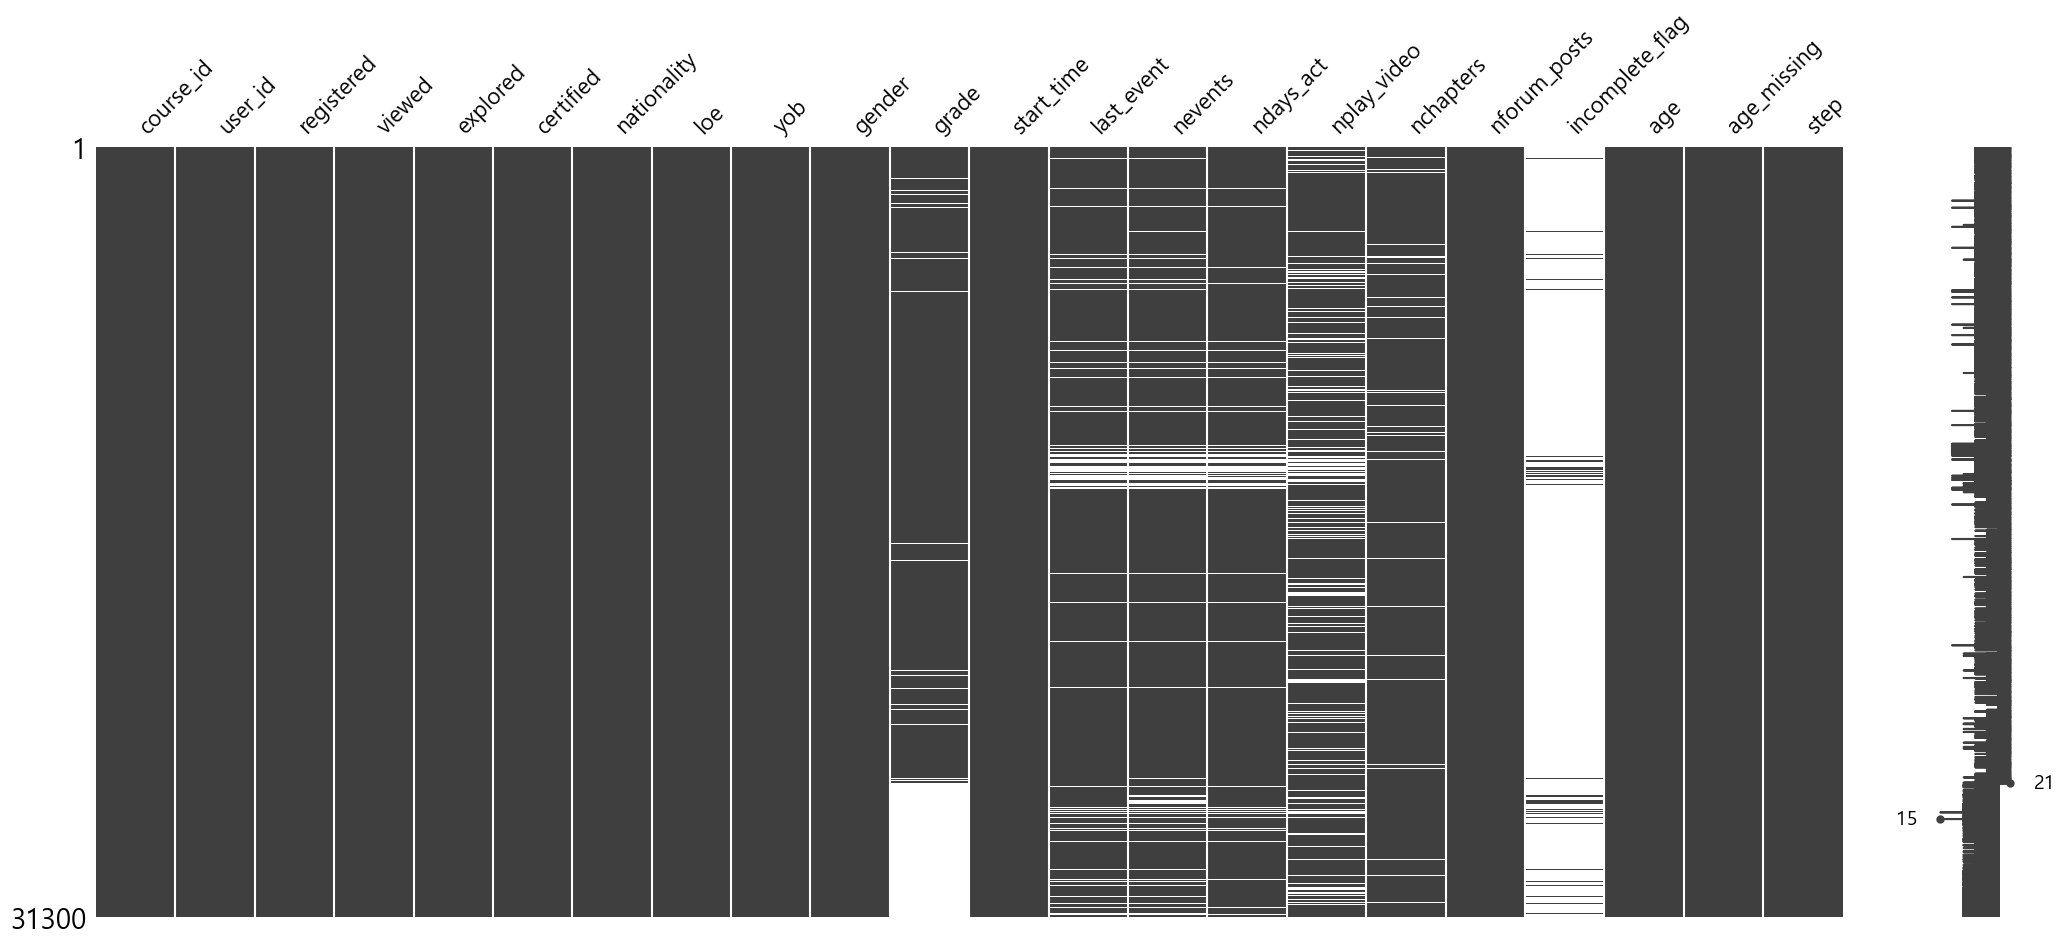

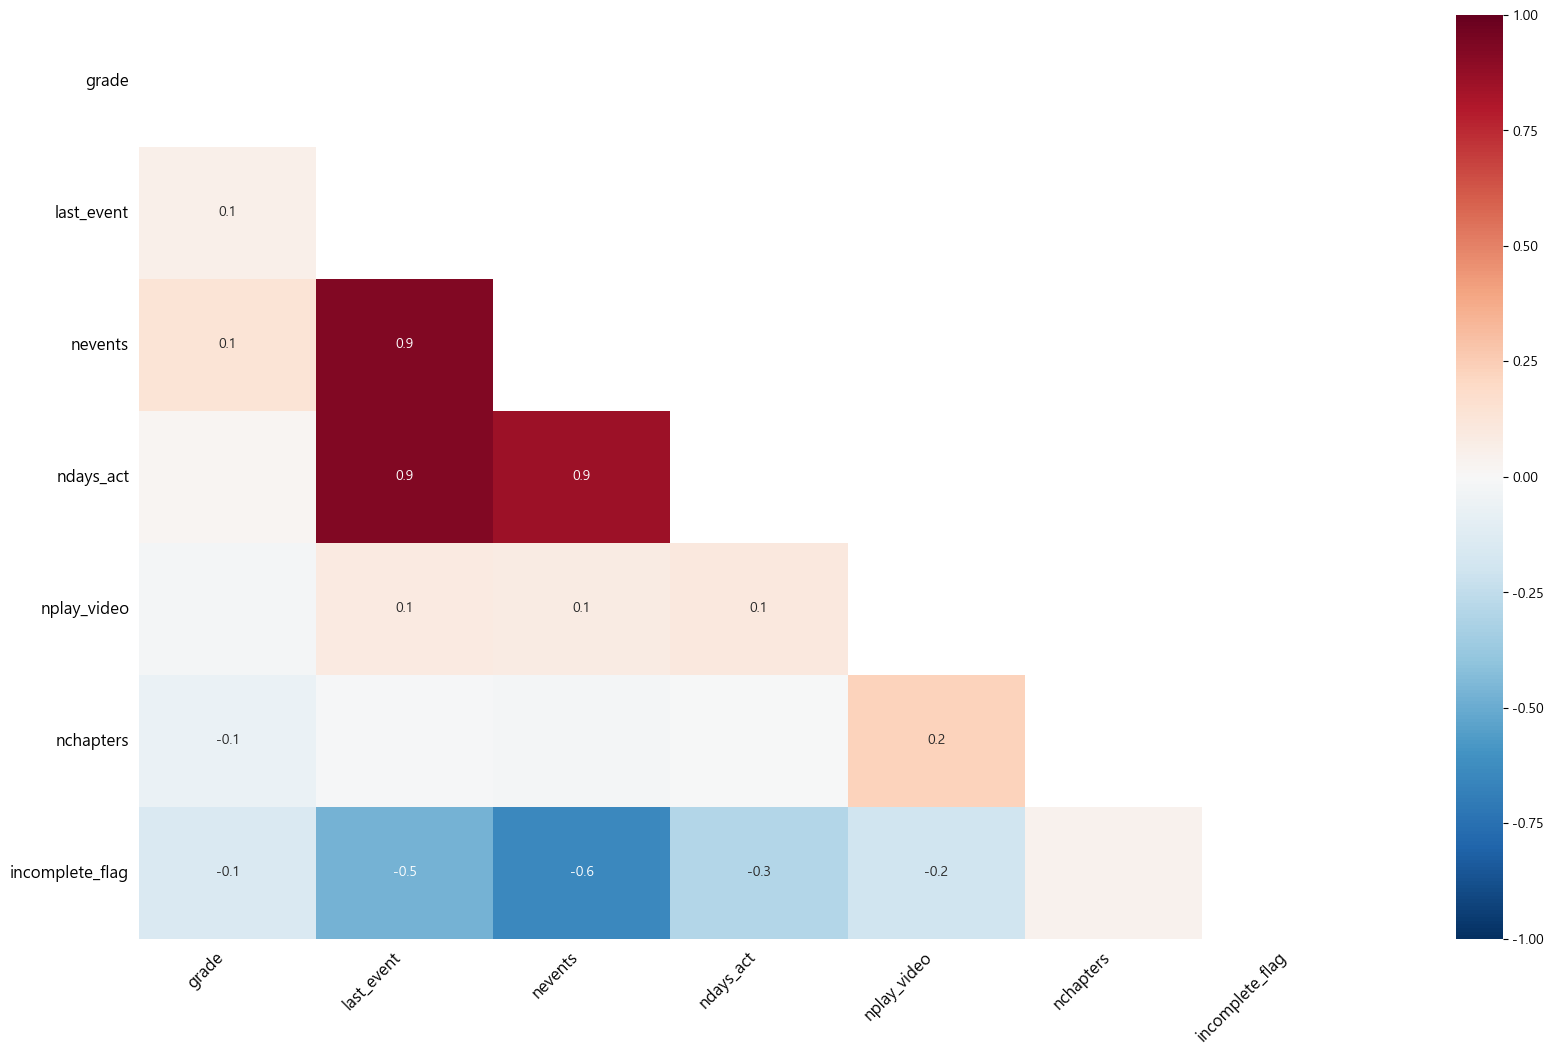

In [355]:
import missingno as msno
import matplotlib.pyplot as plt

# 1. 결측치 위치 시각화 (흰 줄이 결측치)
msno.matrix(nan_target)
plt.show()

# 2. 결측치 간의 상관관계 (A가 비어있을 때 B도 비어있는가?)
msno.heatmap(nan_target, cmap='RdBu_r', fontsize=12)
plt.show()

In [354]:
print(len(nan_target[nan_target['last_event'].isna() 
    & nan_target['nevents'].isna() 
    & nan_target['ndays_act'].isna()]))

2279
